In [1]:
import os
import numpy as np
import tensorflow as tf
tf.config.run_functions_eagerly(True)

import tensorflow_hub as hub
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_fscore_support
)

from imblearn.over_sampling import SMOTE

tf.config.set_visible_devices([], 'GPU')  # force CPU use

print("TensorFlow:", tf.__version__)





TensorFlow: 2.15.0


In [2]:
# IMPORTANT: your dataset path
BASE_DIR = r"G:\SAIKRISHNA_WORKSPACE\SAI\Major_Projects_2025\Akhil\VTPDL05\CODE\fan_split_dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

TARGET_SR = 16000  # YAMNet expects 16 kHz mono

LABEL_MAP = {"normal": 0, "abnormal": 1}
INV_LABEL_MAP = {0: "normal", 1: "abnormal"}

In [3]:
def collect_files(split_dir, split_name):
    filepaths, labels = [], []
    
    for machine_id in sorted(os.listdir(split_dir)):
        machine_path = os.path.join(split_dir, machine_id)
        if not os.path.isdir(machine_path):
            continue
        
        for class_name in ["normal", "abnormal"]:
            class_path = os.path.join(machine_path, class_name)
            if not os.path.isdir(class_path):
                continue
            
            for fname in os.listdir(class_path):
                if fname.lower().endswith((".wav", ".flac", ".ogg")):
                    filepaths.append(os.path.join(class_path, fname))
                    labels.append(LABEL_MAP[class_name])
    
    filepaths = np.array(filepaths)
    labels = np.array(labels)
    print(f"{split_name}: {len(filepaths)} files "
          f"(normal={np.sum(labels==0)}, abnormal={np.sum(labels==1)})")
    return filepaths, labels


train_files, y_train = collect_files(TRAIN_DIR, "Train")
val_files,   y_val   = collect_files(VAL_DIR,   "Val")
test_files,  y_test  = collect_files(TEST_DIR,  "Test")

Train: 3881 files (normal=2851, abnormal=1030)
Val: 832 files (normal=611, abnormal=221)
Test: 837 files (normal=613, abnormal=224)


In [4]:
yamnet_url = "https://tfhub.dev/google/yamnet/1"
yamnet = hub.load(yamnet_url)
print("YAMNet loaded.")

YAMNet loaded.


In [5]:
def load_audio(filepath, target_sr=TARGET_SR):
    audio, sr = librosa.load(filepath, sr=None, mono=True)
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    return audio.astype(np.float32)

In [6]:
def yamnet_sequence_embeddings(waveform):
    """
    waveform: 1D float tensor/array at 16 kHz
    returns: numpy array of shape (T, 1024)
    """
    waveform_tf = tf.convert_to_tensor(waveform, dtype=tf.float32)
    scores, embeddings, spectrogram = yamnet(waveform_tf)
    return embeddings.numpy()

In [7]:
lengths = []
for i, fp in enumerate(train_files[:200]):  # sample first 200 for speed
    wf = load_audio(fp)
    emb = yamnet_sequence_embeddings(wf)
    lengths.append(len(emb))

lengths = np.array(lengths)
print("Sample of sequence lengths (first 200 files):")
print("min:", lengths.min(), "max:", lengths.max(), "mean:", lengths.mean())

Sample of sequence lengths (first 200 files):
min: 20 max: 20 mean: 20.0


In [8]:
MAX_SEQ = 100  # you can adjust based on previous cell if needed

def pad_sequence(seq, max_len=MAX_SEQ):
    """
    seq: (T, 1024)
    returns: (max_len, 1024)
    """
    T, D = seq.shape
    if T >= max_len:
        return seq[:max_len]
    else:
        pad_len = max_len - T
        pad = np.zeros((pad_len, D), dtype=np.float32)
        return np.vstack([seq, pad])

In [9]:
def build_seq_dataset(filepaths, labels, name):
    X_list = []
    y_list = []
    
    for i, (fp, lab) in enumerate(zip(filepaths, labels)):
        if (i + 1) % 100 == 0:
            print(f"{name}: processed {i+1}/{len(filepaths)}")
        
        wf = load_audio(fp)
        seq = yamnet_sequence_embeddings(wf)   # (T, 1024)
        seq_padded = pad_sequence(seq)         # (MAX_SEQ, 1024)
        
        X_list.append(seq_padded)
        y_list.append(lab)
    
    X = np.stack(X_list)   # (N, MAX_SEQ, 1024)
    y = np.array(y_list)
    
    print(f"{name} X shape: {X.shape}, y shape: {y.shape}")
    return X, y


X_train, y_train = build_seq_dataset(train_files, y_train, "Train")
X_val,   y_val   = build_seq_dataset(val_files,   y_val,   "Val")
X_test,  y_test  = build_seq_dataset(test_files,  y_test,  "Test")

Train: processed 100/3881
Train: processed 200/3881
Train: processed 300/3881
Train: processed 400/3881
Train: processed 500/3881
Train: processed 600/3881
Train: processed 700/3881
Train: processed 800/3881
Train: processed 900/3881
Train: processed 1000/3881
Train: processed 1100/3881
Train: processed 1200/3881
Train: processed 1300/3881
Train: processed 1400/3881
Train: processed 1500/3881
Train: processed 1600/3881
Train: processed 1700/3881
Train: processed 1800/3881
Train: processed 1900/3881
Train: processed 2000/3881
Train: processed 2100/3881
Train: processed 2200/3881
Train: processed 2300/3881
Train: processed 2400/3881
Train: processed 2500/3881
Train: processed 2600/3881
Train: processed 2700/3881
Train: processed 2800/3881
Train: processed 2900/3881
Train: processed 3000/3881
Train: processed 3100/3881
Train: processed 3200/3881
Train: processed 3300/3881
Train: processed 3400/3881
Train: processed 3500/3881
Train: processed 3600/3881
Train: processed 3700/3881
Train: pro

In [14]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler


# Flatten sequences: (N, MAX_SEQ * 1024)
N_train, T_len, D_dim = X_train.shape
X_train_flat = X_train.reshape(N_train, -1)

print("Before Resampling:", X_train_flat.shape, y_train.shape)

# STEP 1 — Undersample majority class (normal)
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_tmp, y_tmp = rus.fit_resample(X_train_flat, y_train)
print("After UnderSampling:", X_tmp.shape, y_tmp.shape)

# STEP 2 — Oversample minority class (abnormal)
ros = RandomOverSampler(sampling_strategy="auto", random_state=42)
X_bal_flat, y_bal = ros.fit_resample(X_tmp, y_tmp)
print("After OverSampling:", X_bal_flat.shape, y_bal.shape)

# STEP 3 — Reshape back to sequence format for GRU
X_train_bal = X_bal_flat.reshape(-1, T_len, D_dim)
y_train_bal = y_bal

print("\nFinal balanced shape:", X_train_bal.shape, y_train_bal.shape)

Before Resampling: (3881, 102400) (3881,)
After UnderSampling: (3090, 102400) (3090,)
After OverSampling: (4120, 102400) (4120,)

Final balanced shape: (4120, 100, 1024) (4120,)


In [15]:
def show_balance(labels, name):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} class distribution:")
    for u, c in zip(unique, counts):
        print(f"  {INV_LABEL_MAP[u]} ({u}): {c}")

show_balance(y_train, "Original Train")
show_balance(y_train_bal, "Balanced Train (SMOTE)")
show_balance(y_val, "Val")
show_balance(y_test, "Test")


Original Train class distribution:
  normal (0): 2851
  abnormal (1): 1030

Balanced Train (SMOTE) class distribution:
  normal (0): 2060
  abnormal (1): 2060

Val class distribution:
  normal (0): 611
  abnormal (1): 221

Test class distribution:
  normal (0): 613
  abnormal (1): 224


In [16]:
from tensorflow.keras import layers, models

def build_stronger_gru_model(seq_len=MAX_SEQ, feat_dim=1024):
    inp = layers.Input(shape=(seq_len, feat_dim), name="yamnet_seq")

    x = layers.Bidirectional(
        layers.GRU(256, return_sequences=True)
    )(inp)
    
    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=False)
    )(x)
    
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = models.Model(inputs=inp, outputs=out, name="YAMNet_GRU_Anomaly")
    return model


model = build_stronger_gru_model()
model.summary()

Model: "YAMNet_GRU_Anomaly"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 yamnet_seq (InputLayer)     [(None, 100, 1024)]       0         
                                                                 
 bidirectional (Bidirection  (None, 100, 512)          1969152   
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 256)               493056    
 onal)                                                           
                                                                 
 dense (Dense)               (None, 128)               32896     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 output (Dense)              (None, 1)          

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled.")

Model compiled.


In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "yamnet_gru_smote_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

C:\Users\Python1\anaconda3\envs\vtpip09\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/30



129/129 [==============================] - 488s 4s/step - loss: 0.6707 - accuracy: 0.5779 - auc: 0.6137 - val_loss: 0.6689 - val_accuracy: 0.5252 - val_auc: 0.6527
Epoch 2/30
129/129 [==============================] - 491s 4s/step - loss: 0.6306 - accuracy: 0.6272 - auc: 0.6869 - val_loss: 0.6103 - val_accuracy: 0.6250 - val_auc: 0.6980
Epoch 3/30
129/129 [==============================] - 508s 4s/step - loss: 0.5979 - accuracy: 0.6706 - auc: 0.7346 - val_loss: 0.5925 - val_accuracy: 0.6418 - val_auc: 0.7237
Epoch 4/30
129/129 [==============================] - 519s 4s/step - loss: 0.5775 - accuracy: 0.6903 - auc: 0.7559 - val_loss: 0.5834 - val_accuracy: 0.6214 - val_auc: 0.7273
Epoch 5/30
129/129 [==============================] - 504s 4s/step - loss: 0.5503 - accuracy: 0.7107 - auc: 0.7853 - val_loss: 0.6120 - val_accuracy: 0.6178 - val_auc: 0.7577
Epoch 6/30
129/129 [==============================] - 492s 4s/step - loss: 0.5409 - accuracy: 0.7201 - auc: 0.7928 - val_loss: 0.5610 - 

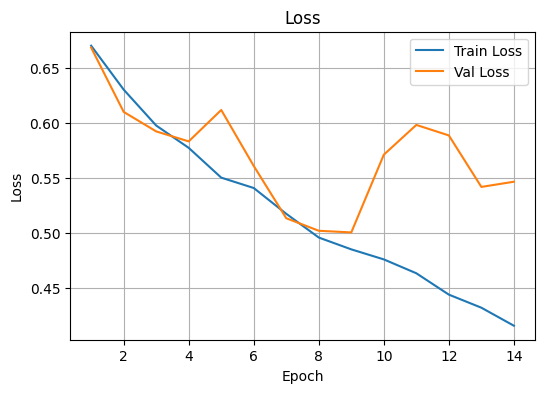

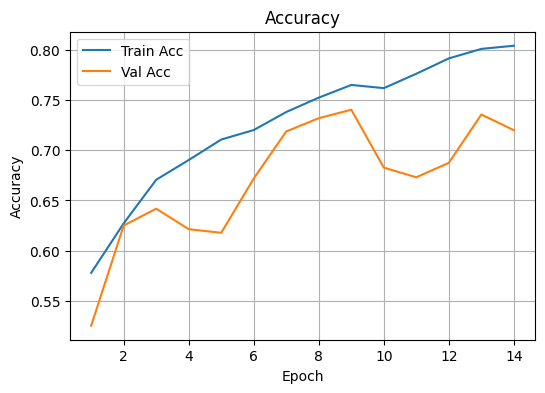

In [19]:
def plot_history(hist):
    h = hist.history
    epochs = range(1, len(h["loss"]) + 1)
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, h["loss"], label="Train Loss")
    plt.plot(epochs, h["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, h["accuracy"], label="Train Acc")
    plt.plot(epochs, h["val_accuracy"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(history)

In [20]:
y_probs = model.predict(X_test).ravel()
y_pred_default = (y_probs >= 0.5).astype(int)

acc_default = accuracy_score(y_test, y_pred_default)
print(f"Test Accuracy (thr=0.5): {acc_default:.4f}\n")

print("Classification Report (thr=0.5):")
print(classification_report(
    y_test,
    y_pred_default,
    target_names=["normal", "abnormal"]
))

cm_default = confusion_matrix(y_test, y_pred_default)
print("Confusion Matrix (thr=0.5):\n", cm_default)

27/27 [==============================] - 42s 2s/step
Test Accuracy (thr=0.5): 0.7372

Classification Report (thr=0.5):
              precision    recall  f1-score   support

      normal       0.83      0.80      0.82       613
    abnormal       0.51      0.56      0.53       224

    accuracy                           0.74       837
   macro avg       0.67      0.68      0.68       837
weighted avg       0.75      0.74      0.74       837

Confusion Matrix (thr=0.5):
 [[491 122]
 [ 98 126]]


In [21]:
thresholds = np.linspace(0.1, 0.9, 17)

best_thr = 0.5
best_f1 = 0.0
best_stats = None

for thr in thresholds:
    y_pred_thr = (y_probs >= thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_thr, average="binary"
    )
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr
        best_stats = (prec, rec, f1)

print(f"Best threshold for abnormal F1: {best_thr:.3f}")
print(f"Precision: {best_stats[0]:.4f}, Recall: {best_stats[1]:.4f}, F1: {best_stats[2]:.4f}")

Best threshold for abnormal F1: 0.450
Precision: 0.4797, Recall: 0.6339, F1: 0.5462


In [22]:
y_pred_best = (y_probs >= best_thr).astype(int)

acc_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy (thr={best_thr:.3f}): {acc_best:.4f}\n")

print(f"Classification Report (thr={best_thr:.3f}):")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["normal", "abnormal"]
))

cm_best = confusion_matrix(y_test, y_pred_best)
print(f"Confusion Matrix (thr={best_thr:.3f}):\n", cm_best)

Test Accuracy (thr=0.450): 0.7180

Classification Report (thr=0.450):
              precision    recall  f1-score   support

      normal       0.85      0.75      0.80       613
    abnormal       0.48      0.63      0.55       224

    accuracy                           0.72       837
   macro avg       0.66      0.69      0.67       837
weighted avg       0.75      0.72      0.73       837

Confusion Matrix (thr=0.450):
 [[459 154]
 [ 82 142]]


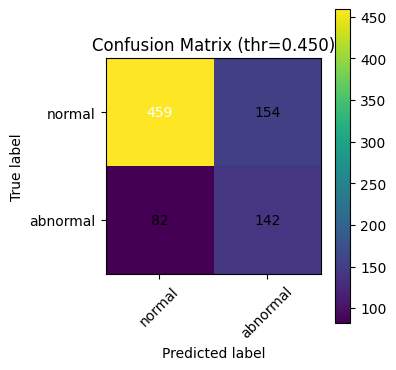

In [23]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(4,4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    fig.colorbar(im)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm_best, ["normal", "abnormal"],
                      title=f"Confusion Matrix (thr={best_thr:.3f})")

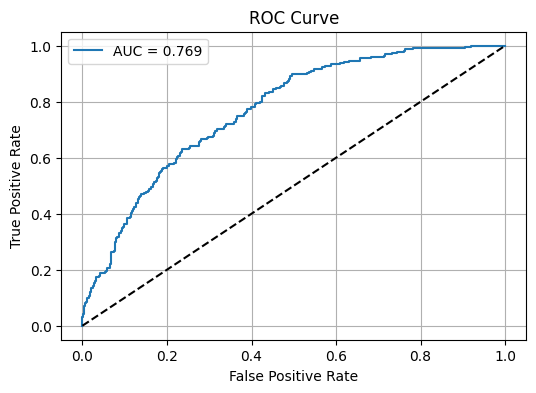

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
MODEL_PATH = "yamnet_gru_smote_tuned.keras"
THRESH_PATH = "best_threshold.txt"

model.save(MODEL_PATH)
print(f"Full model saved at: {MODEL_PATH}")

with open(THRESH_PATH, "w") as f:
    f.write(str(best_thr))

print(f"Best threshold ({best_thr:.3f}) saved at: {THRESH_PATH}")

Full model saved at: yamnet_gru_smote_tuned.keras
Best threshold (0.450) saved at: best_threshold.txt


In [26]:
def show_sample_predictions(
    X, y_true, filepaths, probs, thr, num_samples=10
):
    idxs = np.random.choice(len(y_true), size=min(num_samples, len(y_true)), replace=False)
    for idx in idxs:
        true_label = INV_LABEL_MAP[y_true[idx]]
        p_abn = probs[idx]
        pred_label = INV_LABEL_MAP[int(p_abn >= thr)]
        print("-" * 80)
        print(f"File: {filepaths[idx]}")
        print(f"True Label    : {true_label}")
        print(f"Predicted     : {pred_label}")
        print(f"Abnormal Prob : {p_abn:.4f} (thr={thr:.3f})")

show_sample_predictions(
    X_test, y_test, test_files, y_probs, best_thr, num_samples=10
)

--------------------------------------------------------------------------------
File: G:\SAIKRISHNA_WORKSPACE\SAI\Major_Projects_2025\Akhil\VTPDL05\CODE\fan_split_dataset\test\id_06\normal\00000817.wav
True Label    : normal
Predicted     : normal
Abnormal Prob : 0.0060 (thr=0.450)
--------------------------------------------------------------------------------
File: G:\SAIKRISHNA_WORKSPACE\SAI\Major_Projects_2025\Akhil\VTPDL05\CODE\fan_split_dataset\test\id_02\normal\00000605.wav
True Label    : normal
Predicted     : normal
Abnormal Prob : 0.3298 (thr=0.450)
--------------------------------------------------------------------------------
File: G:\SAIKRISHNA_WORKSPACE\SAI\Major_Projects_2025\Akhil\VTPDL05\CODE\fan_split_dataset\test\id_00\abnormal\00000176.wav
True Label    : abnormal
Predicted     : abnormal
Abnormal Prob : 0.4929 (thr=0.450)
--------------------------------------------------------------------------------
File: G:\SAIKRISHNA_WORKSPACE\SAI\Major_Projects_2025\Akhil\V